## **Optimize Machine Learning Models with Hyperparameter Optimization**

This notebook explores hyperparameter optimization — tuning model settings 
beyond default values to improve performance. Three approaches are
Manual Search, GridSearchCV, and Optuna (Random + Bayesian).

In [2]:
import numpy as np 
import pandas as pd 

df = pd.read_csv('./heart_failure_clinical_records_dataset.csv') #make sure to replace with your data directory
df.drop(columns=['time'],inplace=True) #drop the time column which is not one of the informative features 
df_features = df.iloc[:,:-1]
df_target = df['DEATH_EVENT']

X = df_features
y = df_target

## (0) Manual Research (Validation Set)

In [3]:
# suppress all warnings globally
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

X_train_full, X_test, y_train_full, y_test = train_test_split(X,y, test_size=0.3,stratify=y,random_state=21) # train 70%, test 30%

# create validation set; train 90%, test 10%
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.1, random_state=21, stratify=y_train_full)

print('X train shape: ',X_train.shape)
print('y train shape: ',y_train.shape)
print('X test shape: ',X_test.shape)
print('y test shape: ',y_test.shape)
print('X val shape: ',X_val.shape)
print('y val shape: ',y_val.shape)
print('y train: ',y_train.value_counts(normalize=True))
print('y test: ',y_test.value_counts(normalize=True))
print('y val: ',y_val.value_counts(normalize=True))

# normalize data based on mean and STD of train data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

from sklearn.ensemble import RandomForestClassifier

n_estimators_values = [20, 50, 100, 150, 200]
max_depth_values = [5, 10, 13]

# place to store best score and parameters
best_score = 0
best_params = None

print("Hyperparameter tuning results:\n")

for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        
        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            random_state=42
        )
        
        model.fit(X_train, y_train)
        y_val_pred = model.predict(X_val)
        val_accuracy = accuracy_score(y_val, y_val_pred)
        
        print(f"n_estimators = {n_estimators:<3} | "
              f"max_depth = {str(max_depth):<5} | "
              f"Validation Accuracy = {val_accuracy:.4f}")
        
        if val_accuracy > best_score:
            best_score = val_accuracy
            best_params = {
                "n_estimators": n_estimators,
                "max_depth": max_depth
            }

# print best hyperparameters
print("\nBest Hyperparameters:")
print(best_params)
print(f"Best Validation Accuracy = {best_score:.4f}")

final_model = RandomForestClassifier(
    n_estimators=best_params["n_estimators"],
    max_depth=best_params["max_depth"],
    random_state=42
)

final_model.fit(X_train_full, y_train_full)

# final test evaluation
y_test_pred = final_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"\nFinal Test Accuracy = {test_accuracy:.4f}")

X train shape:  (188, 11)
y train shape:  (188,)
X test shape:  (90, 11)
y test shape:  (90,)
X val shape:  (21, 11)
y val shape:  (21,)
y train:  DEATH_EVENT
0    0.680851
1    0.319149
Name: proportion, dtype: float64
y test:  DEATH_EVENT
0    0.677778
1    0.322222
Name: proportion, dtype: float64
y val:  DEATH_EVENT
0    0.666667
1    0.333333
Name: proportion, dtype: float64
Hyperparameter tuning results:

n_estimators = 20  | max_depth = 5     | Validation Accuracy = 0.8571
n_estimators = 20  | max_depth = 10    | Validation Accuracy = 0.8095
n_estimators = 20  | max_depth = 13    | Validation Accuracy = 0.8571
n_estimators = 50  | max_depth = 5     | Validation Accuracy = 0.8571
n_estimators = 50  | max_depth = 10    | Validation Accuracy = 0.9048
n_estimators = 50  | max_depth = 13    | Validation Accuracy = 0.9048
n_estimators = 100 | max_depth = 5     | Validation Accuracy = 0.8571
n_estimators = 100 | max_depth = 10    | Validation Accuracy = 0.9048
n_estimators = 100 | max_

## (1) GridSearchCV
* GridSearchCV = Grid Search + Cross Validation
* It automates hyperparameter search by exhaustively trying every combination in the parameter grid (Grid Search) and evaluating each using k-fold Cross Validation instead of a single validation set (no need to manually write nested loops).
* In k-fold CV, the training data is split into k equal folds. The model trains on k-1 folds and validates on the remaining fold — repeated k times so every data point gets evaluated exactly once. 
* The final score is the average across all k folds, making it far more reliable than a single train/validation split. This solves the problem of a small validation set being unrepresentative — GridSearchCV finds the hyperparameters that generalize best across the entire training set.
* cv=5 means 5-fold CV — each hyperparameter combination is evaluated 5 times and averaged.

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3,stratify=y,random_state=21)

# normalize data based on mean and STD of train data
scaler = StandardScaler()
X_train_n = scaler.fit_transform(X_train)
X_test_n = scaler.transform(X_test)

model = RandomForestClassifier(random_state=21)

# define parameter grid
# total 150 candidates for hyperparameter (5 X 3 X 5 X 2 = 150)
param_grid = {
    'n_estimators': [20, 50, 100, 150, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 7, 10, 13],
    'max_features': ['sqrt', 'log2']
}

grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_n, y_train)

print("\nBest Hyperparameters:")
print(grid.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(grid.best_score_)

y_test_pred = grid.predict(X_test_n)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("\nFinal Test Accuracy:")
print(test_accuracy)

Fitting 5 folds for each of 150 candidates, totalling 750 fits

Best Hyperparameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 50}

Best Cross-Validation Accuracy:
0.7652729384436701

Final Test Accuracy:
0.7333333333333333


Results:
* GridSearchCV evaluated 150 combinations × 5 folds = 750 total fits.
* Best params: max_depth=10, max_features='sqrt', min_samples_split=5, n_estimators=50
* CV Accuracy: 76.5% → Final Test Accuracy: 73.3% (gap of only ~3%)
* Compare to manual search: Validation 90.5% → Test 32.2% (massive overfitting due to small val set). GridSearchCV gives a much more reliable estimate — the small CV-to-test gap confirms
the model generalizes well and is not overfitting. 
* Tuning improved test accuracy from 72.2% (default RF) to 73.3%.

## (2) Optuna: Modern Hyperparameter Optimization

Optuna is a lightweight framework for advanced hyperparameter optimization. Unlike GridSearchCV which tests all combinations, Optuna intelligently searches the parameter space.

**Key strategies:**
- **Random Search**: Random sampling from search space
- **Bayesian Optimization (TPE)**: Learns from previous trials to propose better parameters

**Benefits:**
- Much faster than GridSearch (especially with expensive models)
- Handles continuous, discrete, and categorical parameters naturally
- Can prune unpromising trials early
- State-of-the-art for real-world problems

### Random Search with Optuna
Random search samples parameters uniformly at random. Simple but effective - just randomly try different combinations and pick the best.

In [12]:
import optuna
from optuna.samplers import RandomSampler
from sklearn.model_selection import cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=21)
scaler = StandardScaler()
X_train_n = scaler.fit_transform(X_train)
X_test_n = scaler.transform(X_test)

def objective_random(trial): # trial = object from optuna
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }
    model = RandomForestClassifier(**params, random_state=21) # RF with parameter that optuna suggested (different for each trial)
    scores = cross_val_score(model, X_train_n, y_train, cv=5, scoring='accuracy')
    return scores.mean()

study_random = optuna.create_study(direction='maximize', sampler=RandomSampler(seed=21))
study_random.optimize(objective_random, n_trials=50, show_progress_bar=True) # repeat 50 times

print(f"Best validation accuracy: {study_random.best_value:.4f}")
print(f"Best params: {study_random.best_params}\n")

# train final model with best params on full training set, then evaluate on test set (once)
best_model_random = RandomForestClassifier(**study_random.best_params, random_state=21)
best_model_random.fit(X_train_n, y_train)
test_acc_random = accuracy_score(y_test, best_model_random.predict(X_test_n))
print(f"Test accuracy: {test_acc_random:.4f}")

[I 2026-02-23 18:18:00,896] A new study created in memory with name: no-name-dc306475-6557-49df-95d9-1e8f39324931


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-02-23 18:18:01,044] Trial 0 finished with value: 0.7702671312427409 and parameters: {'n_estimators': 19, 'max_depth': 11, 'min_samples_split': 15, 'max_features': 'log2'}. Best is trial 0 with value: 0.7702671312427409.
[I 2026-02-23 18:18:01,115] Trial 1 finished with value: 0.7701509872241579 and parameters: {'n_estimators': 19, 'max_depth': 11, 'min_samples_split': 14, 'max_features': 'log2'}. Best is trial 0 with value: 0.7702671312427409.
[I 2026-02-23 18:18:01,192] Trial 2 finished with value: 0.7507549361207898 and parameters: {'n_estimators': 23, 'max_depth': 27, 'min_samples_split': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.7702671312427409.
[I 2026-02-23 18:18:01,767] Trial 3 finished with value: 0.7556329849012775 and parameters: {'n_estimators': 174, 'max_depth': 24, 'min_samples_split': 20, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7702671312427409.
[I 2026-02-23 18:18:02,052] Trial 4 finished with value: 0.746109175377468 and parameter

## (3) Bayesian Optimization (TPE Sampler)

* Bayesian Optimization is smarter - it builds a probability model of the objective function and uses it to propose promising parameter combinations. Tree-structured Parzen Estimator (TPE) is the algorithm that makes this work.
* The key insight: after each trial, we learn something about which parameters work better, so the next trial is more likely to be good.

In [13]:
from optuna.samplers import TPESampler

def objective_bayesian(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 10, 200),
        'max_depth': trial.suggest_int('max_depth', 3, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }
    model = RandomForestClassifier(**params, random_state=21)
    scores = cross_val_score(model, X_train_n, y_train, cv=5, scoring='accuracy')
    return scores.mean()

study_bayesian = optuna.create_study(direction='maximize', sampler=TPESampler(seed=21)) # only this part changed from RandomSampler
study_bayesian.optimize(objective_bayesian, n_trials=50, show_progress_bar=True)

print(f"Best validation accuracy: {study_bayesian.best_value:.4f}")
print(f"Best params: {study_bayesian.best_params}\n")

best_model_bayesian = RandomForestClassifier(**study_bayesian.best_params, random_state=21)
best_model_bayesian.fit(X_train_n, y_train)
test_acc_bayesian = accuracy_score(y_test, best_model_bayesian.predict(X_test_n))
print(f"Test accuracy: {test_acc_bayesian:.4f}")

[I 2026-02-23 18:18:18,633] A new study created in memory with name: no-name-f933721c-fc25-4713-985e-a7fec2d4ed92


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-02-23 18:18:18,706] Trial 0 finished with value: 0.7702671312427409 and parameters: {'n_estimators': 19, 'max_depth': 11, 'min_samples_split': 15, 'max_features': 'log2'}. Best is trial 0 with value: 0.7702671312427409.
[I 2026-02-23 18:18:18,774] Trial 1 finished with value: 0.7701509872241579 and parameters: {'n_estimators': 19, 'max_depth': 11, 'min_samples_split': 14, 'max_features': 'log2'}. Best is trial 0 with value: 0.7702671312427409.
[I 2026-02-23 18:18:18,856] Trial 2 finished with value: 0.7507549361207898 and parameters: {'n_estimators': 23, 'max_depth': 27, 'min_samples_split': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.7702671312427409.
[I 2026-02-23 18:18:19,371] Trial 3 finished with value: 0.7556329849012775 and parameters: {'n_estimators': 174, 'max_depth': 24, 'min_samples_split': 20, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.7702671312427409.
[I 2026-02-23 18:18:19,647] Trial 4 finished with value: 0.746109175377468 and parameter

## Quick Comparison

|  | GridSearchCV | Random Search | Bayesian (TPE) |
|---|---|---|---|
| **Speed** | Slow (tests all) | Medium | Fast (learns) |
| **# Evaluations** | All combinations | Fixed budget | Fixed budget |
| **Best for** | Small grids | Simple & parallel | **Real projects** |
| **Pros** | Exhaustive | Simple | Most efficient |
| **Cons** | Expensive | No learning | Slightly complex |

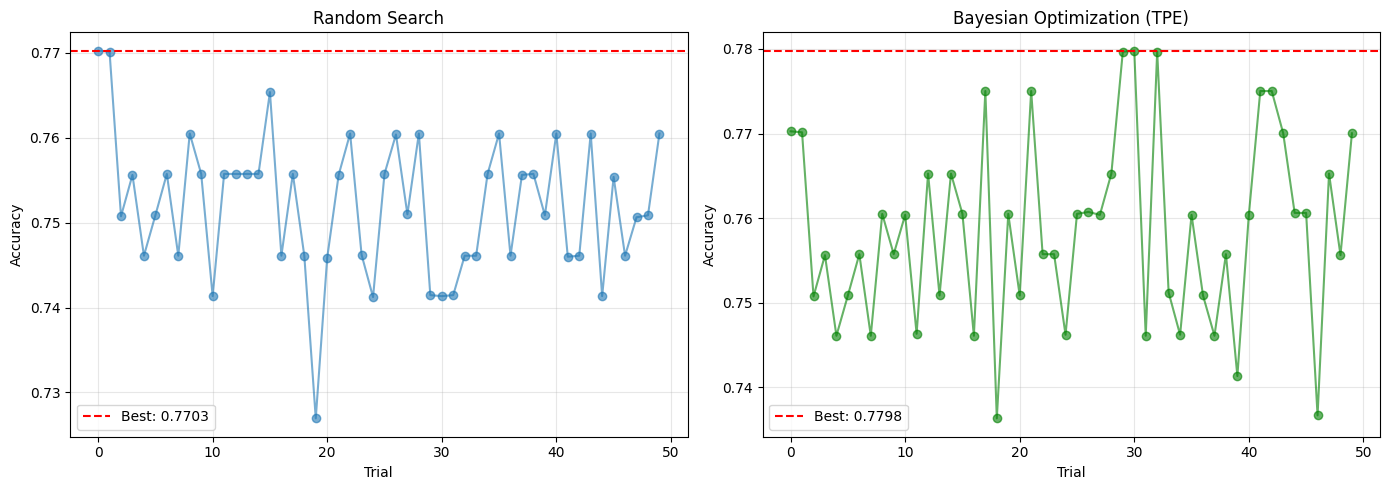

Method               Val Acc         Test Acc       
--------------------------------------------------
Random Search        0.7703          0.7556         
Bayesian (TPE)       0.7798          0.7333         


In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

random_vals = [t.value for t in study_random.trials]
bayesian_vals = [t.value for t in study_bayesian.trials]

axes[0].plot(random_vals, 'o-', alpha=0.6)
axes[0].axhline(y=study_random.best_value, color='r', linestyle='--', label=f'Best: {study_random.best_value:.4f}')
axes[0].set_title('Random Search')
axes[0].set_xlabel('Trial'), axes[0].set_ylabel('Accuracy')
axes[0].legend(), axes[0].grid(True, alpha=0.3)

axes[1].plot(bayesian_vals, 'o-', alpha=0.6, color='green')
axes[1].axhline(y=study_bayesian.best_value, color='r', linestyle='--', label=f'Best: {study_bayesian.best_value:.4f}')
axes[1].set_title('Bayesian Optimization (TPE)')
axes[1].set_xlabel('Trial'), axes[1].set_ylabel('Accuracy')
axes[1].legend(), axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("="*50)
print(f"{'Method':<20} {'Val Acc':<15} {'Test Acc':<15}")
print("-"*50)
print(f"{'Random Search':<20} {study_random.best_value:<15.4f} {test_acc_random:<15.4f}")
print(f"{'Bayesian (TPE)':<20} {study_bayesian.best_value:<15.4f} {test_acc_bayesian:<15.4f}")
print("="*50)

## When to Use What?

**GridSearchCV** → Small, well-defined parameter grid

**Random Search** → Large search space, easy parallelization needed

**Bayesian Optimization (Optuna)** → **Use this for most real projects!**
- Expensive objective function (long model training)
- Mix of continuous and discrete parameters
- Want best results with reasonable compute
- Working on actual problems (not toy examples)